## Import thư viện cần thiết

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

## 1. Bài toán Dự báo Nhu cầu sản phẩm

### Data Preprocessing

In [42]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
#Link dataset: https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci/data
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "online_retail_II.csv"

# Load the latest version
df_retail = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "mashlyn/online-retail-ii-uci",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)
# Xem nhanh dữ liệu
print(f"Kích thước ban đầu: {df_retail.shape}")
df_retail.head()

/tmp/ipykernel_4674/3259336492.py:11: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_retail = kagglehub.load_dataset(


Using Colab cache for faster access to the 'online-retail-ii-uci' dataset.
Kích thước ban đầu: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [43]:

# Chuyển đổi định dạng ngày tháng
df_retail['InvoiceDate'] = pd.to_datetime(df_retail['InvoiceDate'])

# Loại bỏ đơn hàng hủy (Quantity < 0) và chỉ giữ lại đơn hàng có giá sản phẩm > 0
df_retail = df_retail[df_retail['Quantity'] > 0]
df_retail = df_retail[df_retail['Price'] > 0]

# Loại bỏ các mã StockCode không phải hàng hóa (Postage, Bank Charges,...) - thường các mã này chỉ có chữ, không có số hoặc mã đặc biệt
df_retail = df_retail[df_retail['StockCode'].str.contains(r'\d', na=False)]

# Xử lý giá trị thiếu
# Đối với tồn kho, nếu không có Customer ID vẫn có thể dùng để dự báo nhu cầu chung
# nhưng Description bị thiếu thì nên bỏ
df_retail.dropna(subset=['Description'], inplace=True)

# Tính tổng doanh thu
df_retail['TotalRevenue'] = df_retail['Quantity'] * df_retail['Price']

#Loại bỏ 1% outlies (bỏ 1% những đơn hàng có quality lớn nhất)
# Xác định ngưỡng phân vị thứ 99
upper_limit = df_retail['Quantity'].quantile(0.99)
lower_limit = df_retail['Quantity'].quantile(0.01)

# Lọc dữ liệu trong khoảng an toàn và tạo một bản sao rõ ràng để tránh SettingWithCopyWarning
df_filtered = df_retail[(df_retail['Quantity'] < upper_limit) & (df_retail['Quantity'] > lower_limit)].copy()


print(f"Ngưỡng trên: {upper_limit}")
print(f"Số lượng dòng bị loại bỏ 1%: {len(df_retail) - len(df_filtered)}")

# Chia sản phẩm thành các nhóm giá (Ví dụ: Thấp, Trung bình, Cao)
df_filtered['Price_Category'] = pd.qcut(df_filtered['Price'], q=3, labels=[0, 1, 2])

print(f"Kích thước sau khi làm sạch: {df_retail.shape}")

Ngưỡng trên: 100.0
Số lượng dòng bị loại bỏ 1%: 304300
Kích thước sau khi làm sạch: (1037322, 9)


### Features Engineering

In [44]:
def create_time_features(data):
    df_feat = data.copy()
    df_feat['year'] = df_feat['InvoiceDate'].dt.year
    df_feat['month'] = df_feat['InvoiceDate'].dt.month
    df_feat['day'] = df_feat['InvoiceDate'].dt.day
    df_feat['dayofweek'] = df_feat['InvoiceDate'].dt.dayofweek
    df_feat['weekofyear'] = df_feat['InvoiceDate'].dt.isocalendar().week.astype(int)
    return df_feat

# Để dự báo tồn kho, chúng ta thường gom nhóm theo ngày/tuần
# Ví dụ: Tổng nhu cầu của từng sản phẩm theo từng ngày
daily_demand = df_retail.groupby(['StockCode', pd.Grouper(key='InvoiceDate', freq='D')])['Quantity'].sum().reset_index()

# Áp dụng hàm tạo feature
daily_demand = create_time_features(daily_demand)
daily_demand.head()

,StockCode,InvoiceDate,Quantity,year,month,day,dayofweek,weekofyear
0,10002,2009-12-01,12,2009,12,1,1,49
1,10002,2009-12-03,7,2009,12,3,3,49
2,10002,2009-12-04,73,2009,12,4,4,49
3,10002,2009-12-06,49,2009,12,6,6,49
4,10002,2009-12-07,2,2009,12,7,0,50


#### Tạo Lag Features
Lag features là các biến đầu vào trong mô hình dự báo được tạo ra bằng cách lấy giá trị quá khứ của chuỗi thời gian tại 1 hoặc nhiều thời điểm trước đó. Kỹ thuật này giúp mô hình học được mối quan hệ giữa dữ liệu hiện tại và quá khứ.
Với bài toán này, nhóm tạo lag-features dựa trên số lượng sản phẩm của 1 ngày trước và 7 ngày trước.

In [45]:
# Tạo lag 1 ngày, 7 ngày cho từng sản phẩm
daily_demand['lag_1'] = daily_demand.groupby('StockCode')['Quantity'].shift(1)
daily_demand['lag_7'] = daily_demand.groupby('StockCode')['Quantity'].shift(7)

daily_demand['rolling_mean_7'] = daily_demand.groupby('StockCode')['Quantity'].shift(1).rolling(window=7).mean()
daily_demand['rolling_mean_30'] = daily_demand.groupby('StockCode')['Quantity'].shift(1).rolling(window=30).mean()
# Xóa các dòng NaN do quá trình shift tạo ra
daily_demand.dropna(inplace=True)

### Prediction Model: Linear Regression và XGBoost

#### Chia Train Test
Vì bài toán dự báo time-series, nên không chia train test ngẫu nhiên, mà lấy thời gian quá khứ để train. Chia 80% dòng đầu tiên (đã xếp theo thứ tự thời gian) để train, 20% còn lại để test.

In [46]:
# Sắp xếp lại dữ liệu theo thời gian
daily_demand = daily_demand.sort_values('InvoiceDate')

# Chọn các biến features và biến target
features_retail = ['month', 'dayofweek', 'weekofyear', 'lag_1', 'lag_7', 'rolling_mean_7', 'rolling_mean_30']
target_retail = 'Quantity'

# Chia dữ liệu: Dùng 80% đầu để train, 20% cuối để test
train_size = int(len(daily_demand) * 0.8)
train_retail = daily_demand.iloc[:train_size]
test_retail = daily_demand.iloc[train_size:]

X_train_retail, y_train_retail = train_retail[features_retail], train_retail[target_retail]

X_test_retail, y_test_retail = test_retail[features_retail], test_retail[target_retail]

#### Build Models

In [48]:
# --- Model 1: Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train_retail, y_train_retail)
lr_preds = lr_model.predict(X_test_retail)

# --- Model 2: XGBoost ---
# Biến đổi Log cho biến mục tiêu tập Train
y_train_log = np.log1p(y_train_retail)

# Train với y_train_log
# Thêm tham số n_jobs=-1 để chạy nhanh hơn nếu dữ liệu lớn
xgb_model = XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=5, n_jobs=-1)
xgb_model.fit(X_train_retail, y_train_log)

# Dự báo và chuyển ngược về đơn vị gốc
xgb_preds_log = xgb_model.predict(X_test_retail)
xgb_preds_final = np.expm1(xgb_preds_log)


#### Đánh giá models

In [49]:
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"--- {model_name} ---")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2 Score: {r2:.4f}\n")

evaluate_model(y_test_retail, lr_preds, "Linear Regression")
evaluate_model(y_test_retail, xgb_preds_final, "XGBoost")

--- Linear Regression ---
MAE: 19.97
RMSE: 59.06
R2 Score: 0.1519

--- XGBoost ---
MAE: 16.55
RMSE: 60.47
R2 Score: 0.1109



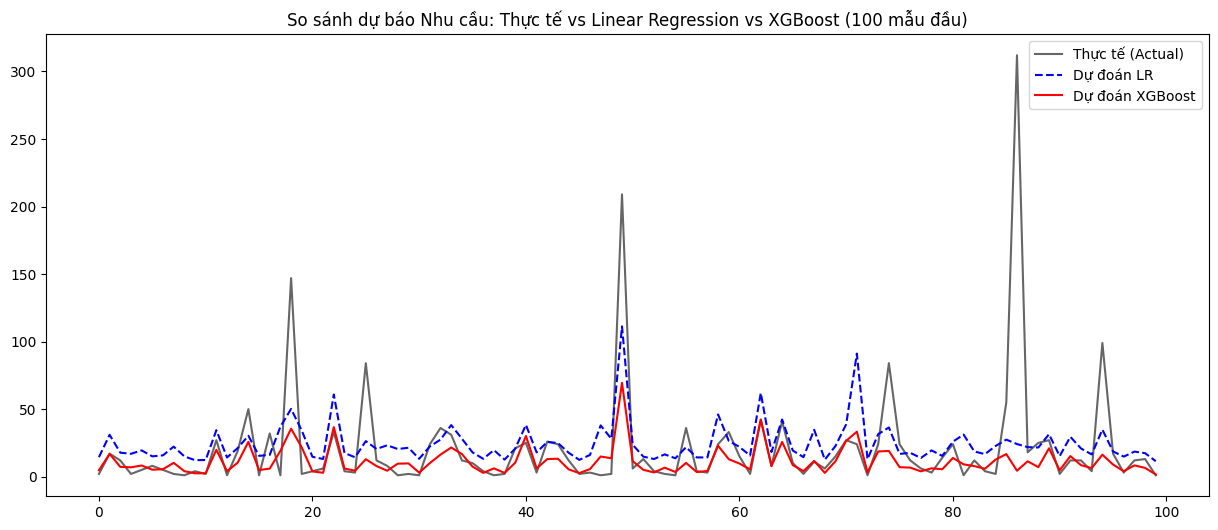

In [50]:
plt.figure(figsize=(15, 6))
plt.plot(y_test_retail.values[:100], label='Thực tế (Actual)', color='black', alpha=0.6)
plt.plot(lr_preds[:100], label='Dự đoán LR', linestyle='--', color='blue')
plt.plot(xgb_preds_final[:100], label='Dự đoán XGBoost', linestyle='-', color='red')
plt.title('So sánh dự báo Nhu cầu: Thực tế vs Linear Regression vs XGBoost (100 mẫu đầu)')
plt.legend()
plt.show()

### Cải tiến thuật toán: Kết hợp Linear Regression và XGBoost
- Lấy trung bình cộng kết quả của 2 thuật toán
- Dùng kết quả của mô hình cải tiến làm phân tích đề xuất

In [15]:
# Kết hợp dự báo của cả hai mô hình (Trung bình cộng)
final_forecast = (lr_preds + xgb_preds_final) / 2

# Tính toán sai số tổ hợp để làm căn cứ cho Safety Stock
combined_rmse = np.sqrt(mean_squared_error(y_test, final_forecast))
print(f"RMSE Kết hợp: {combined_rmse:.2f}")

RMSE Kết hợp: 59.32


In [16]:
# Tính toán các chỉ số đánh giá cho dự báo kết hợp (final_forecast)
ensemble_mae = mean_absolute_error(y_test_retail, final_forecast)
ensemble_rmse = np.sqrt(mean_squared_error(y_test_retail, final_forecast))
ensemble_r2 = r2_score(y_test_retail, final_forecast)

print("--- MÔ HÌNH KẾT HỢP (ENSEMBLE) ---")
print(f"MAE: {ensemble_mae:.2f}")
print(f"RMSE: {ensemble_rmse:.2f}")
print(f"R2 Score: {ensemble_r2:.4f}")

--- MÔ HÌNH KẾT HỢP (ENSEMBLE) ---
MAE: 17.64
RMSE: 59.32
R2 Score: 0.1441


#### So sánh kết quả mô hình Linear Regression, XGBoost và mô hình cải tiến

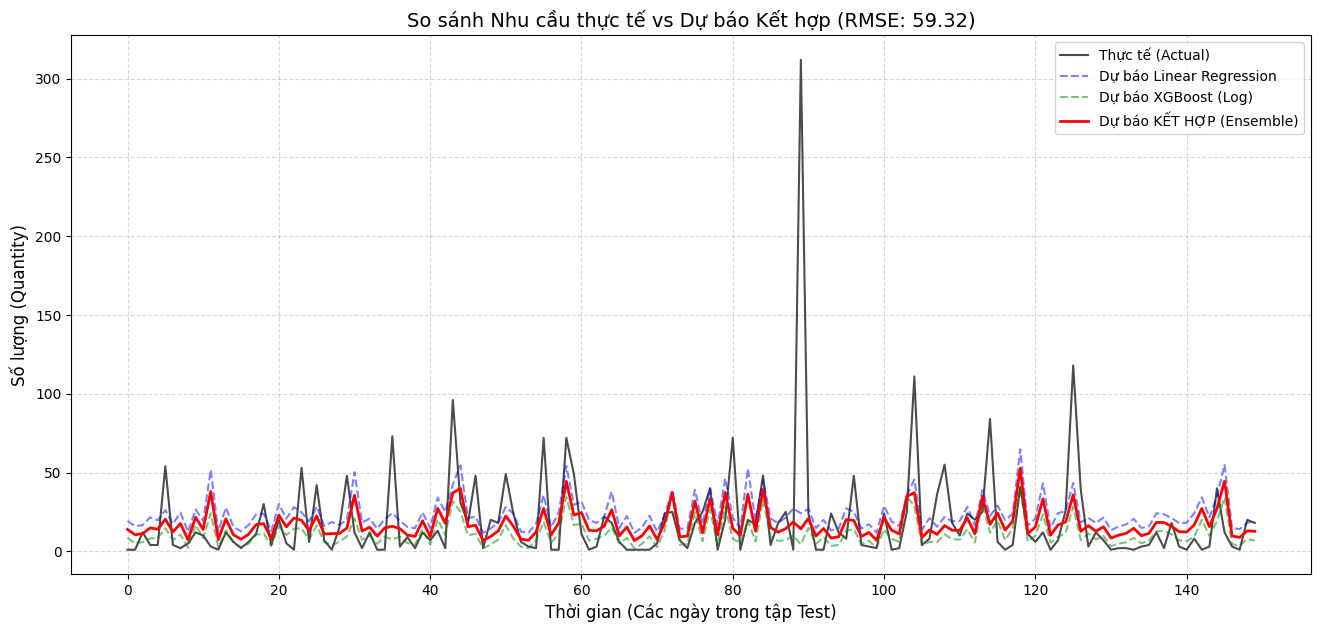

In [17]:
# Chọn một khoảng thời gian hoặc một số lượng mẫu để biểu đồ không bị quá dày
# Chọn 150 mẫu đầu tiên trong tập Test để dễ quan sát
n_samples = 150

plt.figure(figsize=(16, 7))

# Vẽ nhu cầu thực tế
plt.plot(y_test_retail.values[:n_samples], label='Thực tế (Actual)', color='black', linewidth=1.5, alpha=0.7)

# Vẽ dự báo của Linear Regression
plt.plot(lr_preds[:n_samples], label='Dự báo Linear Regression', linestyle='--', color='blue', alpha=0.5)

# Vẽ dự báo của XGBoost
plt.plot(xgb_preds_final[:n_samples], label='Dự báo XGBoost (Log)', linestyle='--', color='green', alpha=0.5)

# Vẽ dự báo sau khi kết hợp (Ensemble)
plt.plot(final_forecast[:n_samples], label='Dự báo KẾT HỢP (Ensemble)', color='red', linewidth=2)

plt.title(f'So sánh Nhu cầu thực tế vs Dự báo Kết hợp (RMSE: {combined_rmse:.2f})', fontsize=14)
plt.xlabel('Thời gian (Các ngày trong tập Test)', fontsize=12)
plt.ylabel('Số lượng (Quantity)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, which='both', linestyle='--', alpha=0.5)

#### Phân tích đề xuất

In [51]:
from google.colab import files
# Tạo map từ dữ liệu gốc ban đầu
stock_description_map = df_retail[['StockCode', 'Description']].drop_duplicates('StockCode').set_index('StockCode')['Description']
# TÍNH TOÁN RMSE RIÊNG CHO TỪNG SẢN PHẨM
eval_df = test_retail[['StockCode']].copy()
eval_df['Actual'] = y_test_retail.values
eval_df['Predicted'] = final_forecast  # Kết quả từ mô hình Ensemble
eval_df['Squared_Error'] = (eval_df['Actual'] - eval_df['Predicted'])**2

# Tính RMSE cho mỗi StockCode
item_stats = eval_df.groupby('StockCode')['Squared_Error'].mean().reset_index()
item_stats['Item_RMSE'] = np.sqrt(item_stats['Squared_Error'])

# TỔNG HỢP KẾT QUẢ PRESCRIPTIVE ---
# Tạo bảng kết quả cuối cùng
prescriptive_final = test_retail[['StockCode']].drop_duplicates().copy()
# Lấy Description từ dữ liệu gốc để bảng kết quả dễ đọc hơn
prescriptive_final['Description'] = prescriptive_final['StockCode'].map(stock_description_map)

# Lấy giá trị dự báo trung bình của sản phẩm đó trong tập Test (đại diện cho nhu cầu sắp tới)
avg_demand = eval_df.groupby('StockCode')['Predicted'].mean().reset_index()
prescriptive_final = prescriptive_final.merge(avg_demand, on='StockCode', how='left')
prescriptive_final = prescriptive_final.merge(item_stats[['StockCode', 'Item_RMSE']], on='StockCode', how='left')

# ÁP DỤNG CÔNG THỨC QUẢN TRỊ KHO ---
LEAD_TIME = 3
Z_SCORE = 1.65
GLOBAL_RMSE = 59.35 # Giá trị RMSE kết hợp bạn đã tính

# Tính SS tùy chỉnh (có áp dụng mức sàn an toàn bằng 50% RMSE tổng để tránh rủi ro thiếu dữ liệu)
prescriptive_final['Safety_Stock_Custom'] = Z_SCORE * prescriptive_final['Item_RMSE']
prescriptive_final['Safety_Stock_Final'] = prescriptive_final['Safety_Stock_Custom'].apply(lambda x: max(x, GLOBAL_RMSE * 0.5 * Z_SCORE))

# Tính Điểm đặt hàng lại (ROP)
prescriptive_final['Reorder_Point'] = (prescriptive_final['Predicted'] * LEAD_TIME) + prescriptive_final['Safety_Stock_Final']

# Giả lập tồn kho thực tế
prescriptive_final['Current_Stock'] = np.random.randint(20, 250, size=len(prescriptive_final))

# Đề xuất hành động
prescriptive_final['Action_Recommendation'] = np.where(
    prescriptive_final['Current_Stock'] <= prescriptive_final['Reorder_Point'],
    'ORDER NOW',
    'SUFFICIENT INVENTORY'
)
# Hằng số: Giả sử muốn nhập hàng đủ dùng cho 7 ngày tiếp theo (Chu kỳ 1 tuần)
ORDER_CYCLE = 7

# Tính toán lượng hàng cần nhập
# Công thức: (Nhu cầu dự báo * (Thời gian chờ + Chu kỳ dùng hàng)) + SS - Tồn kho thực tế
prescriptive_final['Target_Inventory'] = (prescriptive_final['Predicted'] * (LEAD_TIME + ORDER_CYCLE)) + prescriptive_final['Safety_Stock_Final']

# Lượng hàng cần đặt (Order Quantity)
# Nếu tồn kho hiện tại thấp hơn ROP thì đặt hàng, ngược lại bằng 0
prescriptive_final['Order_Quantity'] = np.where(
    prescriptive_final['Action_Recommendation'] == 'ORDER NOW',
    (prescriptive_final['Target_Inventory'] - prescriptive_final['Current_Stock']).clip(lower=0),
    0
)

# Làm tròn số lượng vì không thể nhập lẻ sản phẩm
prescriptive_final['Order_Quantity'] = np.ceil(prescriptive_final['Order_Quantity']).astype(int)

print(prescriptive_final[prescriptive_final['Order_Quantity'] > 0][['StockCode', 'Description', 'Current_Stock', 'Reorder_Point', 'Order_Quantity']].head(10))

   StockCode                       Description  Current_Stock  Reorder_Point  \
0      23110           PARISIENNE KEY CABINET              55     110.065722   
1      22153   ANGEL DECORATION STARS ON DRESS             84     159.832820   
2      84375     SET OF 20 KIDS COOKIE CUTTERS             67      99.162102   
8      22758  LARGE PURPLE BABUSHKA NOTEBOOK              103     129.673319   
11     22147        FELTCRAFT BUTTERFLY HEARTS             70     372.508452   
12     22580      ADVENT CALENDAR GINGHAM SACK             88      97.416770   
13     22338     STAR DECORATION PAINTED ZINC             173     245.090105   
14     22705                 WRAP GREEN PEARS              49      97.218093   
15     48194                    DOORMAT HEARTS             61     159.828289   
16     48138               DOOR MAT UNION FLAG             63     172.736260   

    Order_Quantity  
0              198  
1              188  
2              150  
8              152  
11            

## 2. Bài toán Dự báo Khách hàng rời bỏ sản phẩm

### Data Preprocessing

In [25]:
# Set the path to the file you'd like to load
file_path = "ecommerce_customer_data.csv"

# Load the latest version
df_churn = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "ihasan88/customer-behavior-and-churn-prediction-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)
df_churn.head()

/tmp/ipykernel_4674/1582497971.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_churn = kagglehub.load_dataset(


Using Colab cache for faster access to the 'customer-behavior-and-churn-prediction-dataset' dataset.


,Customer_ID,Age,Gender,Annual_Income,Spending_Score,Membership_Years,Online_Purchases,Discount_Usage,Churn
0,1,56,Male,69812,88,3.2,92,0.43,1
1,2,69,Female,70500,26,4.3,30,0.23,1
2,3,46,Female,99151,17,8.2,199,0.52,0
3,4,32,Male,78643,71,0.6,153,0.25,0
4,5,60,Female,64900,13,6.7,127,0.94,0


In [26]:
# Kiểm tra kiểu dữ liệu và dữ liệu thiếu
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Customer_ID       2000 non-null   int64  
 1   Age               2000 non-null   int64  
 2   Gender            2000 non-null   object 
 3   Annual_Income     2000 non-null   int64  
 4   Spending_Score    2000 non-null   int64  
 5   Membership_Years  2000 non-null   float64
 6   Online_Purchases  2000 non-null   int64  
 7   Discount_Usage    2000 non-null   float64
 8   Churn             2000 non-null   int64  
dtypes: float64(2), int64(6), object(1)
memory usage: 140.8+ KB


In [27]:
# Desciptive statistics
df_churn.describe()

,Customer_ID,Age,Annual_Income,Spending_Score,Membership_Years,Online_Purchases,Discount_Usage,Churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,43.805500,84089.382500,50.448500,5.248000,97.976000,0.489155,0.310500
std,577.494589,14.929203,37446.608502,28.411793,2.759783,57.314858,0.281573,0.462814
min,1.000000,18.000000,20112.000000,1.000000,0.500000,1.000000,0.000000,0.000000
25%,500.750000,31.000000,50810.750000,25.000000,2.875000,50.000000,0.250000,0.000000
50%,1000.500000,44.000000,84476.500000,50.500000,5.200000,93.000000,0.480000,0.000000
75%,1500.250000,56.000000,115550.750000,75.250000,7.700000,147.000000,0.730000,1.000000
max,2000.000000,69.000000,149936.000000,99.000000,10.000000,199.000000,1.000000,1.000000


In [28]:
# Check Customer_ID is unique
df_churn['Customer_ID'].nunique()

2000

In [33]:
# Transform categorical values to numeric: female: 1, male: 0
df_churn['Gender'] = df_churn['Gender'].apply(lambda x: 1 if x == 'Female' else 0)

In [35]:
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Customer_ID       2000 non-null   int64  
 1   Age               2000 non-null   int64  
 2   Gender            2000 non-null   int64  
 3   Annual_Income     2000 non-null   int64  
 4   Spending_Score    2000 non-null   int64  
 5   Membership_Years  2000 non-null   float64
 6   Online_Purchases  2000 non-null   int64  
 7   Discount_Usage    2000 non-null   float64
 8   Churn             2000 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 140.8 KB


### Prediction Model: GradientBoosting

#### Feature Engineering

In [36]:
# Features
features = ['Age', 'Gender', 'Annual_Income', 'Spending_Score', 'Membership_Years', 'Online_Purchases', 'Discount_Usage']
X = df_churn[features]
y = df_churn['Churn']

#### Data Splitting: Chia ngẫu nhiên 80% dữ liệu train, 20% dữ liệu test

In [37]:
#Data Spliting (80% train - 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#### Build Model và đánh giá

--- PIPELINE: Gradient Boosting ---

Model: Gradient Boosting
              precision    recall  f1-score   support

           0       0.69      0.61      0.64       276
           1       0.31      0.40      0.35       124

    accuracy                           0.54       400
   macro avg       0.50      0.50      0.50       400
weighted avg       0.57      0.54      0.55       400

---------Confusion Matrix----------


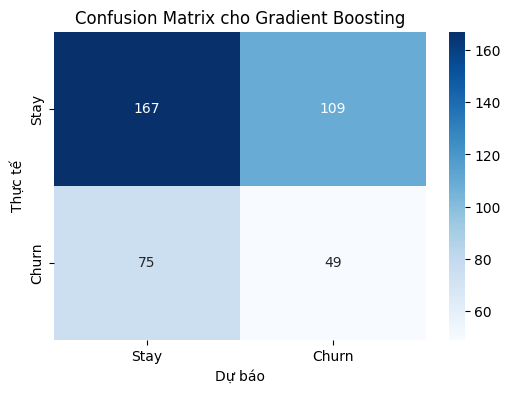

In [41]:
# Mô hình Gradient Boosting
models = {
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}
smote = SMOTE(sampling_strategy='minority', random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print("--- PIPELINE: Gradient Boosting ---")
for name, model in models.items():
    pipe_base = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    # Huấn luyện
    pipe_base.fit(X_train_sm, y_train_sm)

    # Dự báo
    y_pred = pipe_base.predict(X_test)

    print(f"\nModel: {name}")
    print(classification_report(y_test, y_pred, zero_division=0))


    print("---------Confusion Matrix----------")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Stay', 'Churn'], yticklabels=['Stay', 'Churn'])
    plt.xlabel('Dự báo')
    plt.ylabel('Thực tế')
    plt.title(f'Confusion Matrix cho {name}')
    plt.show()